# Stochastic Risk Transfer & Layered Loss Model
## (  Monte Carlo Simulation for Reinsurance Risk Assessment )

## 1. Project Overview
This project develops a **Monte Carlo Simulation** engine to simulate the aggregate loss of an insurance portfolio. By incorporating per-claim policy terms (Deductibles and Limits) and reinsurance structures (Retention), we evaluate the risk distribution from both the insurer's and reinsurer's perspectives.

**Key Objectives:**
* Model claim severity using **heavy-tailed distributions** (Lognormal, Pareto).
* **Risk Quantification**: Utilize **VaR (Value at Risk)** to measure extreme tail risks and solvency requirements.  
* **Contractual Efficacy**: Analyze how policy limits and reinsurance treaties "tame" underlying distribution volatility.  
* Note: Model supports Lognormal, Pareto, Gamma, and Exponential distributions. All distribution-specific parameters are modularly defined within the core functions to allow for seamless benchmarking of various risk profiles.

## 2. Stochastic Modeling & Parameter Setup
We assume claim frequency follows a **Poisson distribution**, and claim severity can be configured with various distributions to reflect different risk profiles.

**Simulation Logic:**
1.  Generate annual claim frequency $N \sim \text{Poisson}(\lambda \times n_{\text{policy}})$.
2.  Generate individual claim sizes $X_i$ based on the selected severity distribution.
3.  Apply policy terms: $Y_i = \min(\max(X_i - \text{Deductible}, 0), \text{Limit})$.
4.  Calculate the risk split:
    * **Insurer's Loss**: $\min(Y_i, \text{Retention})$
    * **Reinsurer's Loss**: $\max(0, Y_i - \text{Retention})$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define function
# Severity distributions 產生損失金額 -----------------------------

def generate_severity(n_claims, dist, params):

    if dist == "lognormal":
        mu, sigma = params
        return np.random.lognormal(mu, sigma, n_claims)

    elif dist == "gamma":
        shape, scale = params
        return np.random.gamma(shape, scale, n_claims)

    elif dist == "exponential":
        scale = params[0]
        return np.random.exponential(scale, n_claims)

    elif dist == "pareto":
        shape = params[0]
        return (np.random.pareto(shape, n_claims) + 1) * 3000

    else:
        raise ValueError("Unsupported distribution")


# Policy structure (deductible & limit) -----------------------------

def compute_payments(claim_sizes, deductible, limit):

    payments = []

    for claim in claim_sizes:

        # deductible
        payment = max(0, claim - deductible)

        # policy limit
        payment = min(payment, limit)

        payments.append(payment)

    return np.array(payments)

# Per-claim reinsurance -----------------------------

def apply_reinsurance(payments, retention):

    insurer_claims = np.minimum(payments, retention)
    reinsurer_claims = np.maximum(0, payments - retention)

    return insurer_claims.sum(), reinsurer_claims.sum()

# Simulation -----------------------------

def per_simulation(n_policy, lambda_freq, dist, params, deductible, limit, retention):

    # frequency - 決定理賠claims次數
    n_claims = np.random.poisson(lambda_freq * n_policy)

    if n_claims == 0:
        return 0,0,0, np.array([])

    # severity - 隨機產生每件理賠案件金額
    claim_sizes = generate_severity(n_claims, dist, params)

    # 計算原始總損失 (Ground-up Loss)
    total_raw_loss = claim_sizes.sum()

    # apply policy terms
    payments = compute_payments(claim_sizes, deductible, limit)

    # reinsurance
    insurer_loss, reinsurer_loss = apply_reinsurance(payments, retention)

    return insurer_loss, reinsurer_loss, total_raw_loss, claim_sizes

# Monte Carlo simulation -----------------------------

def run_simulation(n_sim, n_policy, lambda_freq, dist, params, deductible, limit, retention):
    raw_losses = []
    insurer_losses = []
    reinsurer_losses = []
    all_individual_claims = []
    for i in range(n_sim):
        insurer_loss, reinsurer_loss, raw, individual_claims = per_simulation(n_policy, lambda_freq, dist, params, deductible, limit, retention)
        insurer_losses.append(insurer_loss)
        reinsurer_losses.append(reinsurer_loss)
        raw_losses.append(raw)
        all_individual_claims.extend(individual_claims)
    return np.array(insurer_losses), np.array(reinsurer_losses), np.array(raw_losses), np.array(all_individual_claims)

 ## 3. Simulation Results: Lognormal (Baseline)
The **Lognormal model** serves as the baseline with **10,000 simulations**, I aggregate the annual losses to calculate key solvency metrics.
**Configuration:**
* **Portfolio Size**:  _n_policy = 1,000_
* **Claim Frequency**:  _lambda_freq = 0.2_ (Poisson)
* **Severity Distribution**:  _Lognormal(mu=8, sigma=1)_
* **Policy Terms**:  _Deductible = 1,000_, _Limit = 50,000_
* **Reinsurance**:  _Retention = 20,000_

In [2]:
np.random.seed(42)
insurer, reinsurer, raw, per = run_simulation(n_sim = 10000, n_policy = 1000, lambda_freq = 0.2, dist = "lognormal", params = (8,1), deductible = 1000,
                                    limit = 50000, retention = 20000)

results = pd.DataFrame({"raw": raw,"insurer": insurer,"reinsurer": reinsurer})
raw_loss = results["raw"].mean()
expected_loss = results["insurer"].mean()
var_95 = results["insurer"].quantile(0.95)
var_99 = results["insurer"].quantile(0.99)

# statistics
print("Statistics:\n", results.describe().map(lambda y: f"{y:,.2f}"))
print(f"Expected Raw Loss: {raw_loss:,.0f}")
print(f"Expected Loss: {expected_loss:,.0f}")
print(f"VaR 95%: {var_95:,.0f}")
print(f"VaR 99%: {var_99:,.0f}")

Statistics:
                 raw       insurer   reinsurer
count     10,000.00     10,000.00   10,000.00
mean     982,574.50    731,553.46   51,328.06
std      114,375.15     83,039.19   31,196.61
min      630,889.45    466,805.22        0.00
25%      904,212.60    675,604.87   28,078.98
50%      976,334.20    729,467.64   46,955.09
75%    1,056,637.70    786,267.83   69,648.32
max    1,542,492.91  1,055,357.44  215,485.07
Expected Raw Loss: 982,574
Expected Loss: 731,553
VaR 95%: 872,288
VaR 99%: 931,035


 ## 4. Visualizing the **Net Loss** distribution under the Lognormal assumption

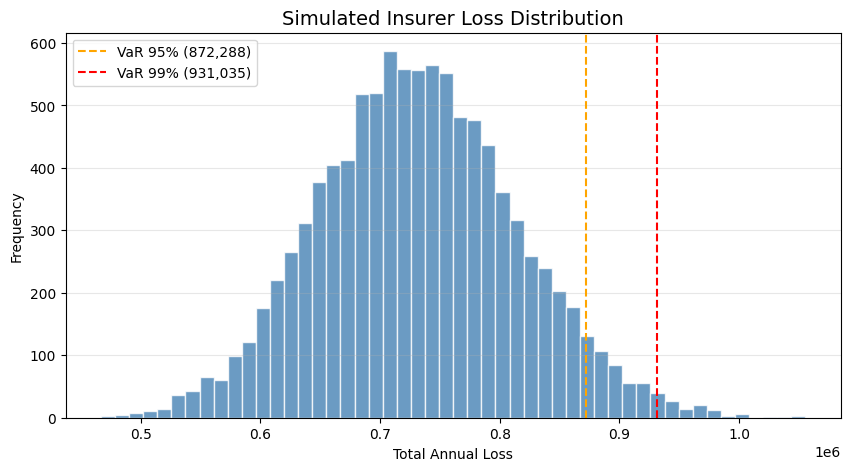

In [3]:
# histogram
plt.figure(figsize=(10, 5))
plt.hist(results["insurer"], bins=50, color='steelblue', edgecolor='white', alpha=0.8)

# 加入 VaR 標示線
plt.axvline(var_95, color='orange', linestyle='--', label=f'VaR 95% ({var_95:,.0f})')
plt.axvline(var_99, color='red', linestyle='--', label=f'VaR 99% ({var_99:,.0f})')

plt.title("Simulated Insurer Loss Distribution", fontsize=14)
plt.xlabel("Total Annual Loss")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 5. Sensitivity Analysis: Heavy-Tailed Distribution (Pareto)
To assess the impact of extreme events, I run a comparative simulation using the **Pareto distribution**.
The Pareto scale was calibrated (using a * 3000 multiplier) to align its Expected Raw Loss (~982,574) with the Lognormal baseline.  
**Configuration:**
* **Severity Distribution**: _Pareto(shape = 2.5)_
* **Note**: All other parameters remained constant, including claim frequency ($\lambda=0.2$),simulation time (10,000), and the contractual structure (Deductibles, Limits, and Reinsurance).

Statistics:
                 raw       insurer   reinsurer
count     10,000.00     10,000.00   10,000.00
mean     999,077.61    777,849.49   16,033.73
std       91,181.79     66,861.98   17,623.88
min      719,189.11    559,887.68        0.00
25%      936,248.26    731,985.07    1,010.24
50%      994,149.06    775,469.42   10,108.78
75%    1,055,658.78    821,652.44   27,749.36
max    1,798,310.26  1,057,240.93  128,813.90
Expected Raw Loss: 999,078
Expected Loss: 777,849
Pareto VaR 95%: 889,752
Pareto VaR 99%: 938,415


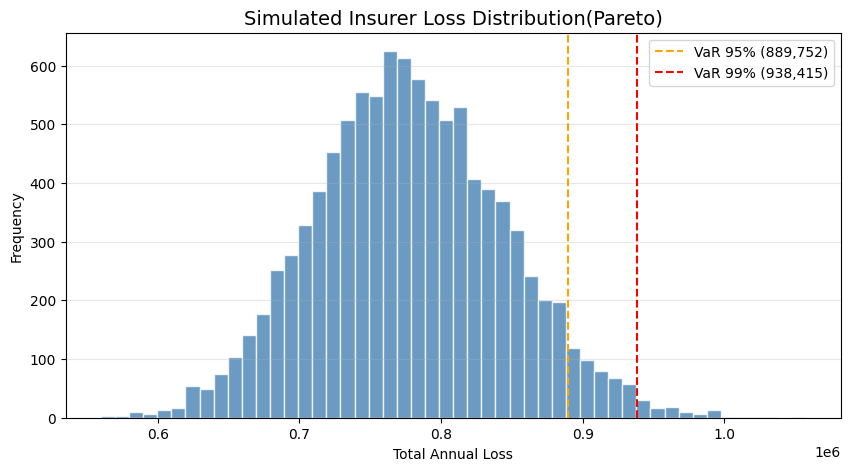

In [4]:
# 實驗 B：Pareto 分配 (Pareto shape = 2.5)
np.random.seed(42)
insurer_p, reinsurer_p, raw_p, per_p = run_simulation(
    n_sim=10000, n_policy=1000, lambda_freq=0.2,
    dist="pareto", params=(2.5,),
    deductible=1000, limit=50000, retention=20000)

results_p = pd.DataFrame({"raw": raw_p,"insurer": insurer_p,"reinsurer": reinsurer_p})
raw_loss_p = results_p['raw'].mean()
expected_loss_p = results_p["insurer"].mean()
var_95_p = results_p["insurer"].quantile(0.95)
var_99_p = results_p["insurer"].quantile(0.99)

print("Statistics:\n", results_p.describe().map(lambda y: f"{y:,.2f}"))
print(f"Expected Raw Loss: {raw_loss_p:,.0f}")
print(f"Expected Loss: {expected_loss_p:,.0f}")
print(f"Pareto VaR 95%: {var_95_p:,.0f}")
print(f"Pareto VaR 99%: {var_99_p:,.0f}")

# histogram
plt.figure(figsize=(10, 5))
plt.hist(results_p["insurer"], bins=50, color='steelblue', edgecolor='white', alpha=0.8)

# 加入 VaR 標示線
plt.axvline(var_95_p, color='orange', linestyle='--', label=f'VaR 95% ({var_95_p:,.0f})')
plt.axvline(var_99_p, color='red', linestyle='--', label=f'VaR 99% ({var_99_p:,.0f})')

plt.title("Simulated Insurer Loss Distribution(Pareto)", fontsize=14)
plt.xlabel("Total Annual Loss")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 6. Raw Loss Distribution Comparison
Before applying any policy structure, we first examine the statistical properties of the ground-up loss for both models.

* The simulated expected loss is very close to the theoretical value.

* The Pareto model exhibits a larger maximum loss, which is a typical characteristic of a heavy-tailed distribution.

🔍 Technical Note: Why is Pareto's Variance Lower?  
_Reason 1 ：_  
To maintain the same mean, the Pareto distribution must cluster most of its values near the lower bound. Since $\alpha=2.5$ yields a finite variance, this high concentration significantly reduces the Standard Deviation compared to the more dispersed Lognormal model.  
_Reason 2 ：_  
Pareto’s risk is characterized by infrequent but massive spikes, whereas Lognormal’s risk is spread across a "fatter" mid-to-high range ($20k–45k$). This "fat body" creates higher consistent volatility, proving that **Volatility $\neq$ Tail Risk**.

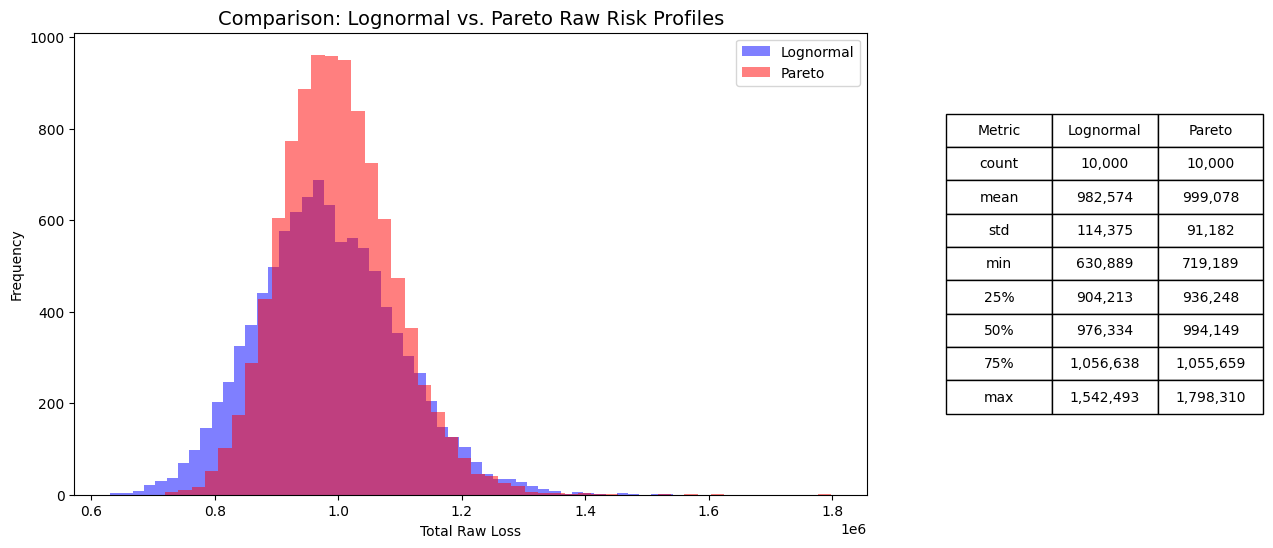

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# 敘述性統計表格
stats_log = results["raw"].describe()
stats_pareto = results_p["raw"].describe()
summary_df = pd.DataFrame({"Metric": stats_log.index,"Lognormal": stats_log.values,"Pareto": stats_pareto.values})
# 格式化數字
summary_df["Lognormal"] = summary_df["Lognormal"].apply(lambda x: f"{x:,.0f}")
summary_df["Pareto"] = summary_df["Pareto"].apply(lambda x: f"{x:,.0f}")

# 繪圖
fig, ax = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [3, 1]})

# 左圖：Histogram
ax[0].hist(results["raw"], bins=50, alpha=0.5, label='Lognormal', color='blue')
ax[0].hist(results_p["raw"], bins=50, alpha=0.5, label='Pareto', color='red')
ax[0].set_title("Comparison: Lognormal vs. Pareto Raw Risk Profiles", fontsize=14)
ax[0].set_xlabel("Total Raw Loss")
ax[0].set_ylabel("Frequency")
ax[0].legend()

# 右圖：Table
ax[1].axis('off')  # 隱藏右邊的座標軸
table = ax[1].table( cellText=summary_df.values, colLabels=summary_df.columns, cellLoc='center', loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)  # 調整表格寬度與高度
plt.show()

## 7. Net Loss Distribution Comparison
  
🔍 **Expected Insurer Loss** : Pareto  > Lognormal.     
Since both distributions were calibrated to the same mean, the Pareto distribution must compensate for its extreme tail by clustering a vast majority of its probability mass near the lower bound. Because these high-frequency claims are concentrated between 1k and 21k, the insurer must retain the loss in full. This accumulation of probability mass in the lower layer leads to a higher expected aggregate loss compared to the Lognormal model.

🔍 **Insurer Loss Volatility** : Pareto  < Lognormal.  
The primary source of Pareto's variance is its "Heavy Tail." However, the Policy Limit acts as a "ceiling" that forcibly truncates (decapitates) all extreme spikes and converts them into a constant payout of 50,000.By "neutralizing" the tail, the insurer is left with a highly concentrated portfolio of small claims.  
🔍 **Expected Reinsurer Loss** : Pareto  < Lognormal.  
This occurs because the reinsurance layer is triggered primarily by claims between 21,000 and 50,000. The Lognormal distribution has a higher probability mass in this range, leading to more frequent reinsurance recoveries.

In contrast, the Pareto distribution generates more very small claims (absorbed by the deductible) and more extremely large claims that are capped by the policy limit.As a result, the reinsurer’s exposure is actually lower under the Pareto severity model.

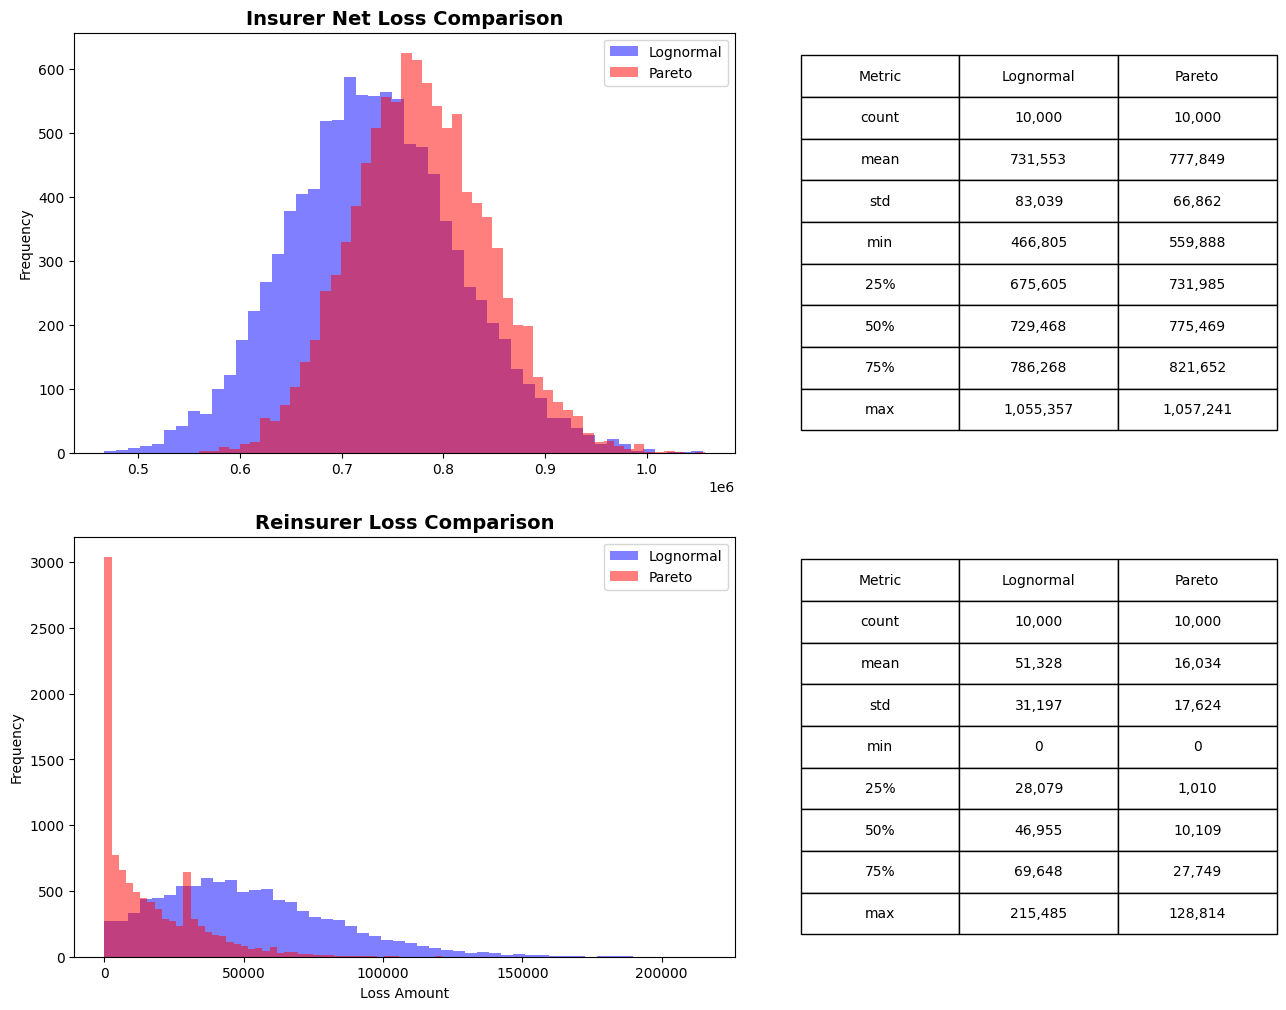

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Insurer&Reinsurer Data
def get_summary(df_l, df_p, col):
    s_l = df_l[col].describe()
    s_p = df_p[col].describe()
    summary = pd.DataFrame({"Metric": s_l.index, "Lognormal": s_l.values, "Pareto": s_p.values})
    summary["Lognormal"] = summary["Lognormal"].apply(lambda x: f"{x:,.0f}")
    summary["Pareto"] = summary["Pareto"].apply(lambda x: f"{x:,.0f}")
    return summary

summary_insurer = get_summary(results, results_p, "insurer")
summary_reinsurer = get_summary(results, results_p, "reinsurer")

# 繪圖 2*2
fig, ax = plt.subplots(2, 2, figsize=(15, 12), gridspec_kw={'width_ratios': [2.5, 1.5]})

# Insurer Loss (左：Insurer Histogram  右：Insurer Table)
ax[0, 0].hist(results["insurer"], bins=50, alpha=0.5, label='Lognormal', color='blue')
ax[0, 0].hist(results_p["insurer"], bins=50, alpha=0.5, label='Pareto', color='red')
ax[0, 0].set_title("Insurer Net Loss Comparison", fontsize=14, fontweight='bold')
ax[0, 0].set_ylabel("Frequency")
ax[0, 0].legend()

ax[0, 1].axis('off')
table1 = ax[0, 1].table(cellText=summary_insurer.values, colLabels=summary_insurer.columns, cellLoc='center', loc='center')
table1.auto_set_font_size(False)
table1.set_fontsize(10)
table1.scale(1.2, 2.5)

# Reinsurer Loss (左：Reinsurer Histogram 右：Reinsurer Table)
ax[1, 0].hist(results["reinsurer"], bins=50, alpha=0.5, label='Lognormal', color='blue')
ax[1, 0].hist(results_p["reinsurer"], bins=50, alpha=0.5, label='Pareto', color='red')
ax[1, 0].set_title("Reinsurer Loss Comparison", fontsize=14, fontweight='bold')
ax[1, 0].set_xlabel("Loss Amount")
ax[1, 0].set_ylabel("Frequency")
ax[1, 0].legend()

ax[1, 1].axis('off')
table2 = ax[1, 1].table(cellText=summary_reinsurer.values, colLabels=summary_reinsurer.columns, cellLoc='center', loc='center')
table2.auto_set_font_size(False)
table2.set_fontsize(10)
table2.scale(1.2, 2.5)
plt.show()

## 8. Supplement: Distribution and Descriptive Statistics of Simulated Individual Claims  
* Recall: insurer's payoff  
0 ~ 1,000          → insurer = $0$  
1,000 ~ 21,000      → insurer = $X-1,000$  
21,000 ~ 50,000            → insurer = $20,000$ (policy limit = 50,000)  
  
**Comparative Analysis of Loss Layers & Risk Structures**
1. Layer 1 (1k - 21k):
Pareto exhibits extreme mass concentration in the lower layer (99.23% vs 83.67%). Even though individual Pareto claims in this zone are small, the sheer frequency of these losses creates a massive "loss foundation" that the insurer must retain in full.    
**📊 Deep Dive**  
* Lognormal (83% of claims): The claims are more heavily skewed towards the very low end. While frequent, these individual amounts are relatively small.
* Pareto (99.2% of claims): Not only are the claims more frequent, but the average claim size within this layer is also higher compared to Lognormal.  

2. Layer 2 (21k - 50k):
Lognormal has a higher density (2.31% vs 0.69%).

**Conclusion on Insurer Loss:**  
Although the Lognormal model generates more individual claims in the mid-tier, it is insufficient to offset the cumulative impact of Pareto’s high-frequency small claims. The combination of higher frequency (99% vs 83%) and higher internal severity (average claim size) within the 1k–21k retention layer creates a "Double Whammy" for the insurer. This explains why the aggregate Insurer Expected Loss remains higher for Pareto; the sheer volume and density of claims in the primary layer outweigh the impact of Lognormal's mid-tier losses, even after the extreme Pareto tail has been truncated by the policy limit.

Individual Claim Severity Statistics:
          Lognormal        Pareto
count  2,000,227.00  1,998,862.00
mean       4,912.31      4,998.23
std        6,427.10      4,129.70
min           23.82      3,000.00
25%        1,516.29      3,366.09
50%        2,978.79      3,957.78
75%        5,846.00      5,219.69
max      372,362.35    913,679.24
--- Lognormal Severity Distribution Analysis ---
1,000 - 21,000 (小額區間): 83.67%
21,000 - 50,000 (中大額區間): 2.31%
Above 50,000 (超額/尾端區間): 0.24%
--- Pareto Severity Distribution Analysis ---
1,000 - 21,000 (小額區間): 99.23%
21,000 - 50,000 (中大額區間): 0.69%
Above 50,000 (超額/尾端區間): 0.09%


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


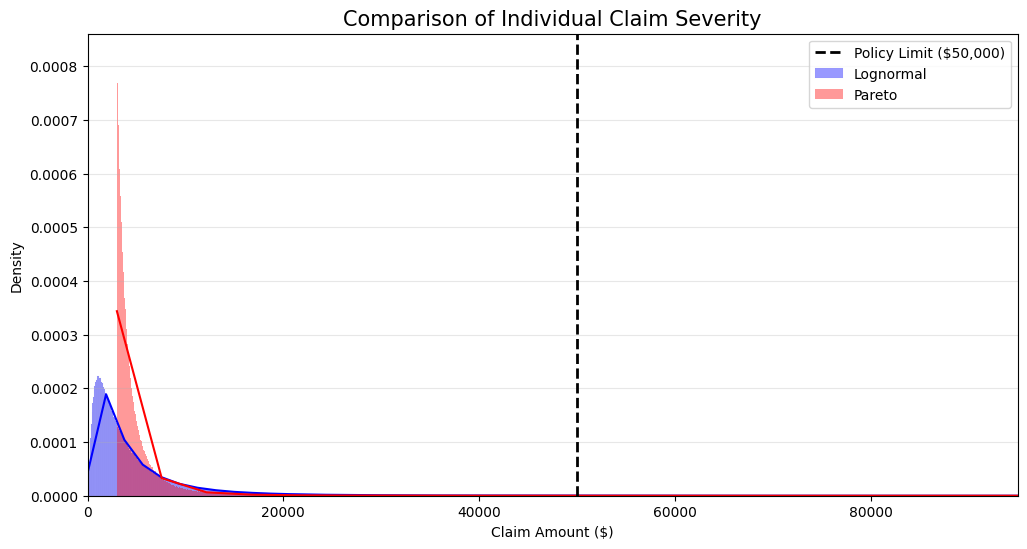

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
def calculate_distribution_ratio(claims, name):
    # 計算各區間數量 & 占比 (mask為 T/F array)
    mask_1k_21k = (claims >= 1000) & (claims < 21000)
    mask_21k_50k = (claims >= 21000) & (claims <= 50000)
    mask_above_50k = (claims > 50000)
    ratio_1k_21k = np.mean(mask_1k_21k) * 100
    ratio_21k_50k = np.mean(mask_21k_50k) * 100
    ratio_above_50k = np.mean(mask_above_50k) * 100

    print(f"--- {name} Severity Distribution Analysis ---")
    print(f"1,000 - 21,000 (小額區間): {ratio_1k_21k:.2f}%")
    print(f"21,000 - 50,000 (中大額區間): {ratio_21k_50k:.2f}%")
    print(f"Above 50,000 (超額/尾端區間): {ratio_above_50k:.2f}%")

# show per claim
df_per = pd.DataFrame({'Lognormal': pd.Series(per),'Pareto': pd.Series(per_p)})

# statistics
per_stats = df_per.describe()
print("Individual Claim Severity Statistics:")
print(per_stats.apply(lambda x: x.apply(lambda y: f"{y:,.2f}")))

# 執行計算
calculate_distribution_ratio(per, "Lognormal")
calculate_distribution_ratio(per_p, "Pareto")

# 繪圖：單筆理賠分布對照
plt.figure(figsize=(12, 6))

# 使用 log=True (Pareto 的尾巴長用對數座標才看得到分佈細節)
sns.histplot(per, color="blue", label="Lognormal", kde=True, stat="density", alpha=0.4)
sns.histplot(per_p, color="red", label="Pareto", kde=True, stat="density", alpha=0.4)
plt.axvline(x=50000, color='black', linestyle='--', linewidth=2, label='Policy Limit ($50,000)') # policy limit 線

# 裝飾圖表
plt.title("Comparison of Individual Claim Severity", fontsize=15)
plt.xlabel("Claim Amount ($)")
plt.ylabel("Density")
plt.xlim(0, 95000) # 限制 X 軸範圍以便觀察，否則 Pareto 極端值會讓圖縮得很小
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

## 🏁 Overall Conclusion: Contractual Reshaping of Risk
This analysis demonstrates that while the Pareto distribution is inherently heavy-tailed, insurance contract structures (deductibles, limits, and reinsurance) fundamentally reshape the loss profile across different layers.

* **The Insurer's Burden:** In the **primary layer (1k–21k)**, Pareto’s extreme concentration of claims creates a massive "loss foundation," leading to a higher expected insurer loss than Lognormal. Conversely, the $50k policy limit "decapitates" Pareto’s extreme tail, significantly lowering its volatility.

* **The Reinsurer's Exposure:** For the reinsurer, the **intermediate layer (21k–50k)** is the primary driver. Since Lognormal places more probability mass in this range, it results in higher reinsurer exposure compared to the truncated Pareto model.

**Actuarial Insight:** Risk is not only a function of the underlying distribution but is critically defined by how contract design allocates it across layers.